# Experiment 3: Implementation of Convolutional Neural Networks (CNNs) for Image Classification


## Part A: Dataset Preparation

In [1]:
# Import required libraries
#24BAD035-Ibrahim
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load the CIFAR-10 dataset (already split into train and test by Keras)
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Full training data shape:", x_train_full.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 976s 6us/step
Full training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [3]:
# Preprocess: normalize pixel values to the range [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten label arrays from (N,1) to (N,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Split the training data into training and validation sets (90% train, 10% validation)
val_split = int(0.9 * len(x_train_full))
x_train, x_val = x_train_full[:val_split], x_train_full[val_split:]
y_train, y_val = y_train_full[:val_split], y_train_full[val_split:]

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


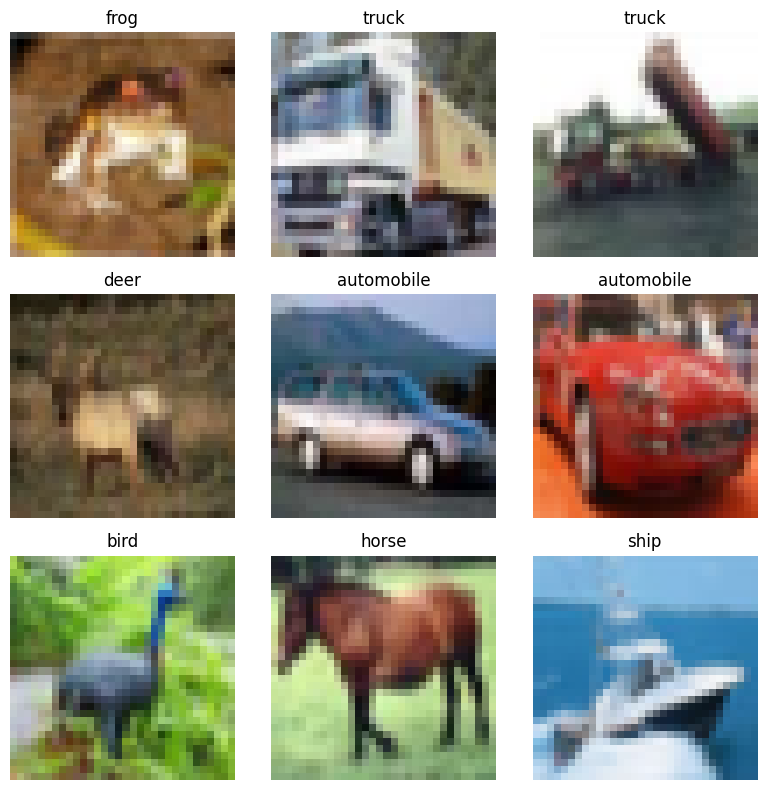

In [4]:
# Visualize a few sample images from the training set
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Part B: CNN Model Implementation


In [5]:
#24BAD035-Ibrahim
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # Softmax output layer, 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model with the Adam optimizer and cross-entropy loss
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # labels are integers, not one-hot
    metrics=['accuracy']
)

## Part C: Model Training and Evaluation

In [7]:
#24BAD035-Ibrahim
EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 282s 395ms/step - accuracy: 0.3812 - loss: 1.6673 - val_accuracy: 0.5430 - val_loss: 1.2757
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 277s 393ms/step - accuracy: 0.5620 - loss: 1.2288 - val_accuracy: 0.6514 - val_loss: 1.0178
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 276s 392ms/step - accuracy: 0.6344 - loss: 1.0408 - val_accuracy: 0.6972 - val_loss: 0.8967
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 320s 389ms/step - accuracy: 0.6868 - loss: 0.9011 - val_accuracy: 0.7314 - val_loss: 0.7717
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 324s 392ms/step - accuracy: 0.7214 - loss: 0.8020 - val_accuracy: 0.7484 - val_loss: 0.7466
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 274s 389ms/step - accuracy: 0.7470 - loss: 0.7319 - val_accuracy: 0.7686 - val_loss: 0.6943
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 276s 391ms/step - accuracy: 0.7693 - loss: 0.6583 - val_accuracy: 0.7596 - val_loss: 0.7343
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 325s 395ms/step - accuracy: 0.7860 -

In [8]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 - 16s - 52ms/step - accuracy: 0.7808 - loss: 0.7793

Test Accuracy: 0.7808
Test Loss: 0.7793


In [9]:
# Print final training and validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Final Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Testing Accuracy          : {test_acc:.4f}")

Final Training Accuracy   : 0.8692
Final Validation Accuracy : 0.7868
Final Training Loss       : 0.3632
Final Validation Loss     : 0.7325
Testing Accuracy          : 0.7808


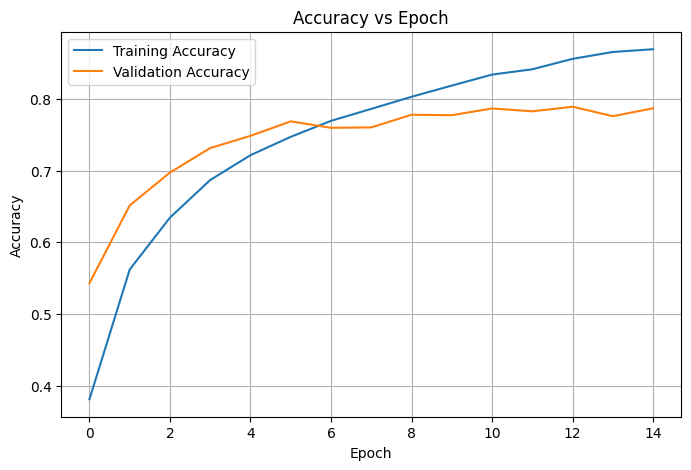

In [10]:
# Plot Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

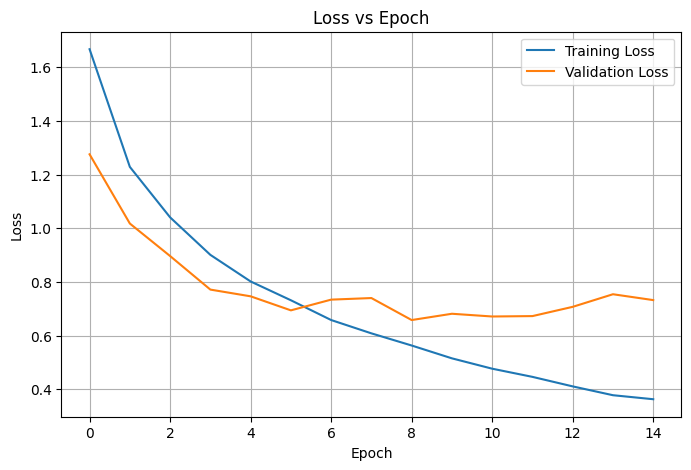

In [11]:
# Plot Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Part D: Performance Analysis

In [12]:
#24BAD035-Ibrahim
#Get model predictions on the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

#Classification report (precision, recall, f1-score per class)
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step
              precision    recall  f1-score   support

    airplane       0.78      0.83      0.81      1000
  automobile       0.92      0.88      0.90      1000
        bird       0.66      0.68      0.67      1000
         cat       0.65      0.57      0.61      1000
        deer       0.73      0.77      0.75      1000
         dog       0.66      0.75      0.70      1000
        frog       0.80      0.83      0.82      1000
       horse       0.87      0.76      0.81      1000
        ship       0.87      0.89      0.88      1000
       truck       0.89      0.84      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



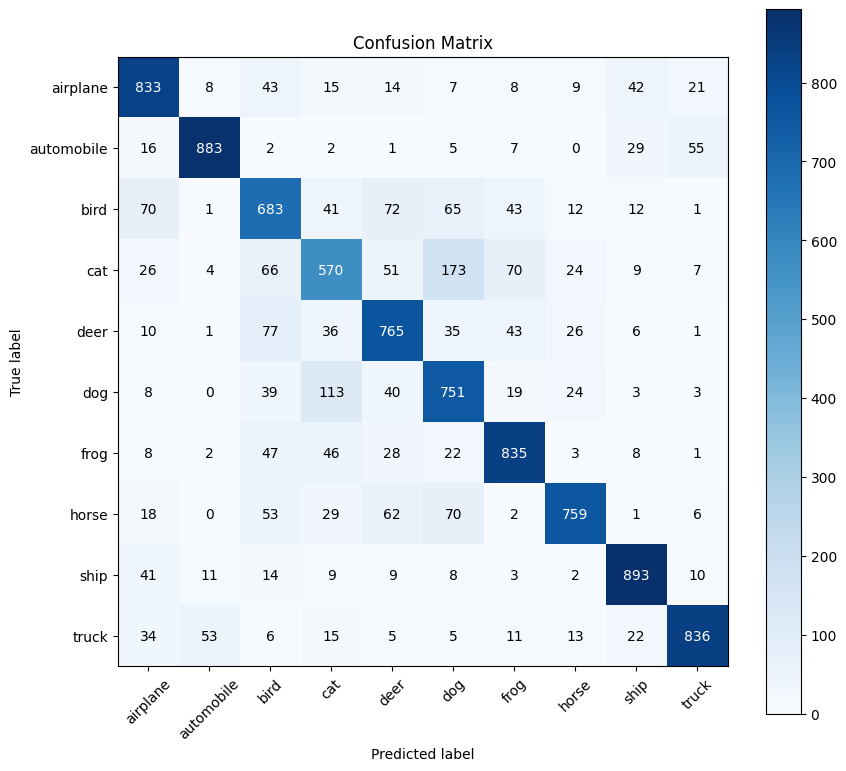

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Annotate cell counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

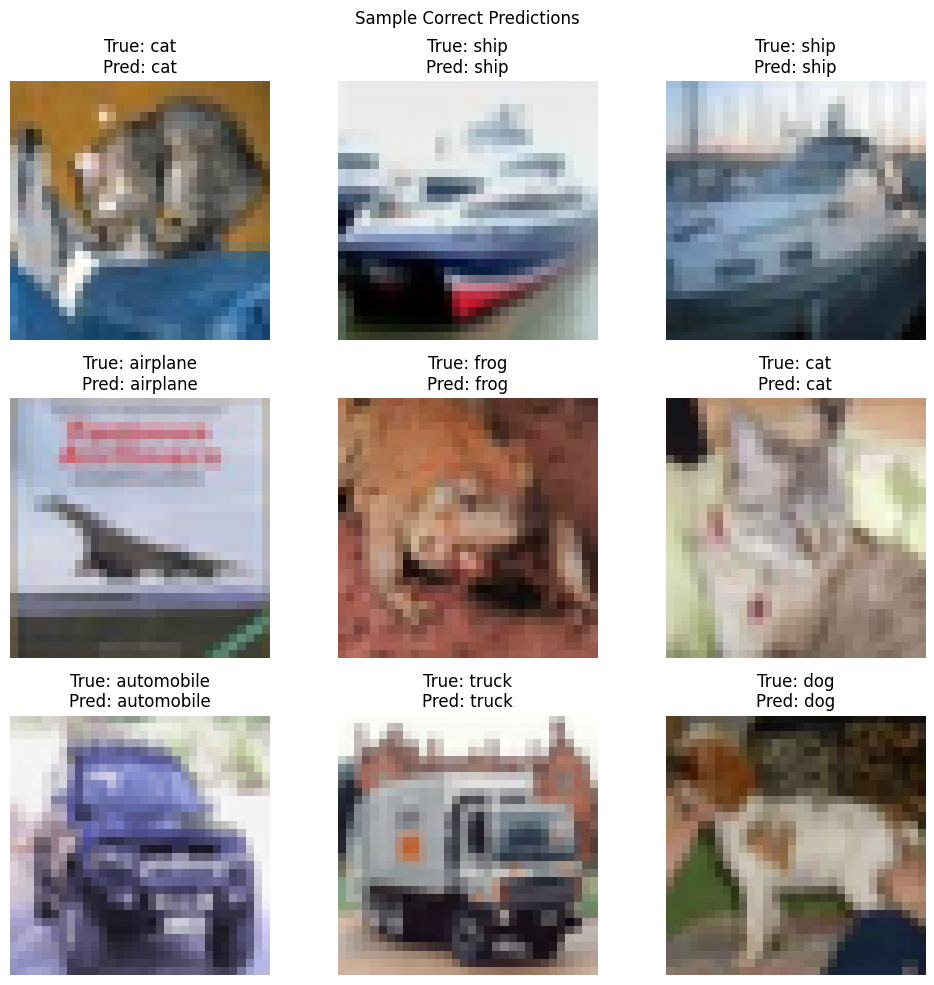

In [14]:
# Sample predictions: correctly classified images
correct_idx = np.where(y_pred == y_test)[0]

plt.figure(figsize=(10, 10))
for i, idx in enumerate(correct_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Sample Correct Predictions")
plt.tight_layout()
plt.show()

Number of misclassified test images: 2192 out of 10000


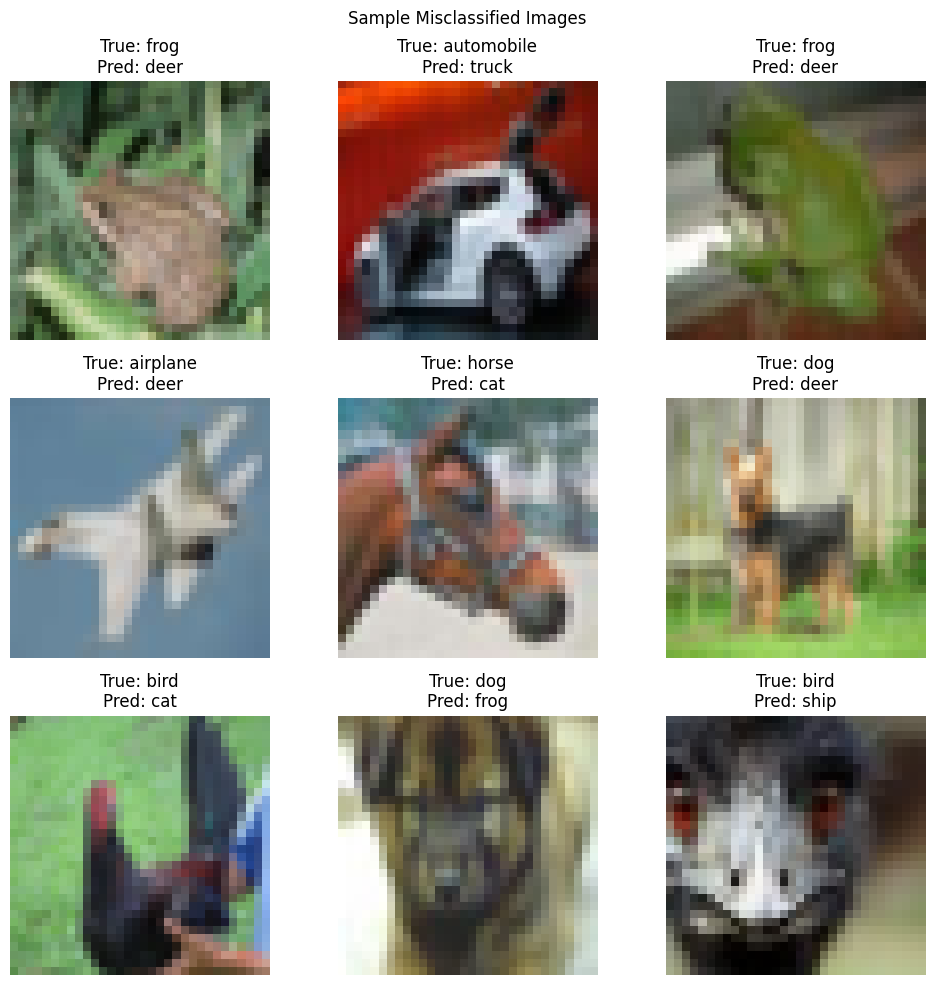

In [15]:
# Misclassified images
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_idx)} out of {len(y_test)}")

plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()